In [23]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.svm import SVC
from itertools import product
from sklearn.base import clone
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.decomposition import PCA
from joblib import Parallel, delayed
from scipy.stats import randint, uniform
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

In [24]:
class MultiModelRandomSearch:
    def __init__(self, train_df: pd.DataFrame, test_df: pd.DataFrame, label_column: str):
        self.label_column = label_column

        self.label_encoder = LabelEncoder()
        train_df[label_column] = self.label_encoder.fit_transform(train_df[label_column])
        test_df[label_column] = self.label_encoder.transform(test_df[label_column])

        drop_cols = [label_column, "uniprot_id", "protein_name", "fold"]
        self.X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
        self.y_train = train_df[label_column]

        self.X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
        self.y_test = test_df[label_column]

        self.models = {
            "RandomForest": RandomForestClassifier(random_state=42),
            "AdaBoost": AdaBoostClassifier(random_state=42)
        }

        self.param_distributions = {
            "RandomForest": {
                "n_estimators": randint(100, 300),
                "max_depth": [None, 10, 20, 30],
                "min_samples_split": randint(2, 10),
                "min_samples_leaf": randint(1, 5),
                "bootstrap": [True, False]
            },
            "AdaBoost": {
                "n_estimators": randint(50, 150),
                "learning_rate": uniform(0.1, 1.0)
            }
        }

        self.results = dict()
        self.best_model = None
        self.best_model_name = ""

    def run_random_search(self, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1):
        for name, model in self.models.items():
            print(f"\nRunning RandomizedSearchCV for {name}...")

            random_search = RandomizedSearchCV(
                estimator=model,
                param_distributions=self.param_distributions[name],
                n_iter=n_iter,
                cv=cv,
                scoring=scoring,
                n_jobs=n_jobs,
                random_state=42,
                verbose=1
            )

            random_search.fit(self.X_train, self.y_train)

            best_model = random_search.best_estimator_
            best_params = random_search.best_params_
            y_pred = best_model.predict(self.X_test)
            acc = accuracy_score(self.y_test, y_pred)

            print(f"{name} - Accuracy: {acc:.4f}")
            print(f"Best Params: {best_params}")
            print("\nClassification Report:\n", classification_report(self.y_test, y_pred))

            self.results[name] = {
                "model": best_model,
                "accuracy": acc,
                "params": best_params,
                "report": classification_report(self.y_test, y_pred, output_dict=True)
            }

        self.best_model_name = max(self.results, key=lambda k: self.results[k]["accuracy"])
        self.best_model = self.results[self.best_model_name]["model"]

        print(f"\nBest Model: {self.best_model_name} with accuracy {self.results[self.best_model_name]['accuracy']:.4f}")

    def get_best_model(self):
        return self.best_model, self.best_model_name

if __name__ == "__main__":
    train_df = pd.read_csv("../processed_data/Split data/train_dd.csv")
    val_df = pd.read_csv("../processed_data/Split data/val_dd.csv")
    test_df = pd.read_csv("../processed_data/Split data/test_dd.csv")

    combined_train_df = pd.concat([train_df, val_df], ignore_index=True)

    selector = MultiModelRandomSearch(
        train_df=combined_train_df,
        test_df=test_df,
        label_column="protein_name"
    )

    selector.run_random_search(n_iter=25)
    best_model, name = selector.get_best_model()


Running RandomizedSearchCV for RandomForest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
RandomForest - Accuracy: 0.7913
Best Params: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 9, 'n_estimators': 257}

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        36
           1       0.67      0.05      0.09        40
           2       0.87      0.98      0.92        46
           3       0.58      0.96      0.72        56
           4       1.00      0.79      0.88        29
           5       1.00      0.96      0.98        23

    accuracy                           0.79       230
   macro avg       0.85      0.79      0.76       230
weighted avg       0.81      0.79      0.74       230


Running RandomizedSearchCV for AdaBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


C:\Users\zafri\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost - Accuracy: 0.6609
Best Params: {'learning_rate': 0.2428668179219408, 'n_estimators': 52}

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.75      0.84        36
           1       0.29      0.05      0.09        40
           2       0.60      0.93      0.73        46
           3       0.53      0.82      0.65        56
           4       0.85      0.59      0.69        29
           5       1.00      0.74      0.85        23

    accuracy                           0.66       230
   macro avg       0.71      0.65      0.64       230
weighted avg       0.66      0.66      0.62       230


Best Model: RandomForest with accuracy 0.7913


In [25]:


class FinalModelEvaluator:
    def __init__(self, model, full_df: pd.DataFrame, label_column: str, n_splits: int = 5):
        self.model = model
        self.data = full_df
        self.label_column = label_column
        self.n_splits = n_splits

        drop_cols = [label_column, "uniprot_id", "protein_name"]
        self.X = self.data.drop(columns=[col for col in drop_cols if col in self.data.columns])
        self.y = self.data[label_column]

        if self.y.dtype == "object":
            from sklearn.preprocessing import LabelEncoder
            self.label_encoder = LabelEncoder()
            self.y = pd.Series(self.label_encoder.fit_transform(self.y), index=self.data.index)
        else:
            self.label_encoder = None

        self.kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)


    def evaluate(self, average='weighted'):
        metrics = {
            "accuracy": [],
            "precision": [],
            "recall": [],
            "f1": [],
            "roc_auc": []
        }

        for fold, (train_idx, val_idx) in enumerate(self.kf.split(self.X)):
            print(f"\nFold {fold + 1}")
            X_train, X_val = self.X.iloc[train_idx], self.X.iloc[val_idx]
            y_train, y_val = self.y.iloc[train_idx], self.y.iloc[val_idx]

            self.model.fit(X_train, y_train)
            y_pred = self.model.predict(X_val)

            metrics["accuracy"].append(accuracy_score(y_val, y_pred))
            metrics["precision"].append(precision_score(y_val, y_pred, average=average, zero_division=0))
            metrics["recall"].append(recall_score(y_val, y_pred, average=average, zero_division=0))
            metrics["f1"].append(f1_score(y_val, y_pred, average=average, zero_division=0))

            try:
                if hasattr(self.model, "predict_proba"):
                    y_proba = self.model.predict_proba(X_val)
                    if len(np.unique(y_val)) == 2:
                        metrics["roc_auc"].append(roc_auc_score(y_val, y_proba[:, 1]))
                    else:
                        metrics["roc_auc"].append(roc_auc_score(y_val, y_proba, multi_class='ovr'))
                else:
                    metrics["roc_auc"].append(np.nan)
            except:
                metrics["roc_auc"].append(np.nan)

        print("\nCross-Validation Results:")
        for metric, scores in metrics.items():
            valid_scores = [s for s in scores if not np.isnan(s)]
            mean_score = np.mean(valid_scores)
            std_score = np.std(valid_scores)
            print(f"{metric.capitalize()}: {mean_score:.4f} ± {std_score:.4f}")

        return metrics

if __name__ == "__main__":
    full_df = pd.read_csv("../processed_data/protein_features/processed_protein_features.csv")
    best_model, model_name = selector.get_best_model()

    evaluator = FinalModelEvaluator(
        model=best_model,
        full_df=full_df,
        label_column="protein_name",
        n_splits=5
    )

    metrics = evaluator.evaluate()




Fold 1

Fold 2

Fold 3

Fold 4

Fold 5

Cross-Validation Results:
Accuracy: 0.7658 ± 0.0143
Precision: 0.7541 ± 0.0227
Recall: 0.7658 ± 0.0143
F1: 0.7558 ± 0.0183
Roc_auc: 0.9301 ± 0.0075


 Finding best PCA components using K-Fold...


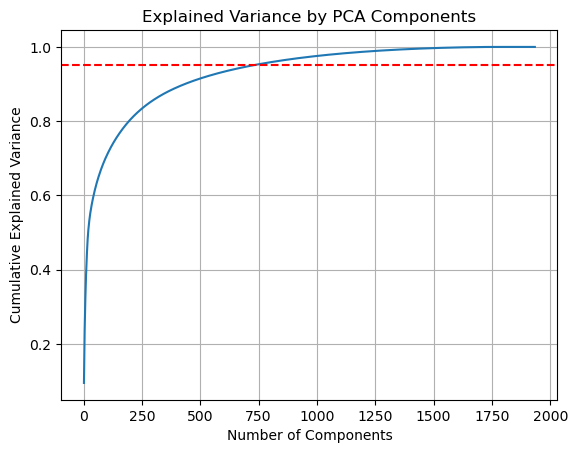

C:\Users\zafri\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


PCA Components: 200 → CV Accuracy: 0.7234
PCA Components: 400 → CV Accuracy: 0.7141
PCA Components: 600 → CV Accuracy: 0.7073
Early stopping: score dropped significantly.

Best PCA components: 200 with CV accuracy: 0.7234

Final Evaluation with 200 PCA components using K-Fold...

Cross-Validation Metrics:
Accuracy: 0.7223 ± 0.0105
Precision: 0.7014 ± 0.0163
Recall: 0.7223 ± 0.0105
F1: 0.7074 ± 0.0138


In [26]:


class PCAKFoldEvaluator:
    def __init__(self, model, full_df: pd.DataFrame, label_column: str, max_components: int = None, n_splits: int = 5):
        self.model = model
        self.label_column = label_column
        self.n_splits = n_splits

        drop_cols = ["uniprot_id", "protein_name", self.label_column]
        self.X = full_df.drop(columns=[col for col in drop_cols if col in full_df.columns])
        self.y = full_df[label_column]

        if self.y.dtype == 'object':
            self.label_encoder = LabelEncoder()
            self.y = pd.Series(self.label_encoder.fit_transform(self.y), index=full_df.index)
        else:
            self.label_encoder = None

        self.max_components = max_components if max_components else min(self.X.shape)
        self.kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    def find_best_n_components(self, step=5, early_stop_threshold=0.001, plot_variance=True):
        print(" Finding best PCA components using K-Fold...")

        pca_full = PCA(n_components=self.max_components)
        X_full_pca = pca_full.fit_transform(self.X)

        best_score = 0
        best_n = 0

        if plot_variance:
            explained = np.cumsum(pca_full.explained_variance_ratio_)
            plt.plot(range(1, len(explained) + 1), explained)
            plt.axhline(y=0.95, color='r', linestyle='--')
            plt.title("Explained Variance by PCA Components")
            plt.xlabel("Number of Components")
            plt.ylabel("Cumulative Explained Variance")
            plt.grid(True)
            plt.show()

        for n in range(step, self.max_components + 1, step):
            X_pca = X_full_pca[:, :n]
            scores = cross_val_score(clone(self.model), X_pca, self.y, cv=self.kf, scoring="accuracy", n_jobs=-1)
            mean_score = np.mean(scores)
            print(f"PCA Components: {n} → CV Accuracy: {mean_score:.4f}")

            if mean_score > best_score + early_stop_threshold:
                best_score = mean_score
                best_n = n
            elif best_score - mean_score > 0.01:
                print("Early stopping: score dropped significantly.")
                break

        print(f"\nBest PCA components: {best_n} with CV accuracy: {best_score:.4f}")
        return best_n

    def final_evaluation(self, n_components):
        print(f"\nFinal Evaluation with {n_components} PCA components using K-Fold...")

        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(self.X)

        metrics = {
            "accuracy": [],
            "precision": [],
            "recall": [],
            "f1": []
        }

        for fold, (train_idx, val_idx) in enumerate(self.kf.split(X_pca)):
            X_train, X_val = X_pca[train_idx], X_pca[val_idx]
            y_train, y_val = self.y[train_idx], self.y[val_idx]

            model = clone(self.model)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            metrics["accuracy"].append(accuracy_score(y_val, y_pred))
            metrics["precision"].append(precision_score(y_val, y_pred, average='weighted', zero_division=0))
            metrics["recall"].append(recall_score(y_val, y_pred, average='weighted', zero_division=0))
            metrics["f1"].append(f1_score(y_val, y_pred, average='weighted', zero_division=0))

        print("\nCross-Validation Metrics:")
        for metric, scores in metrics.items():
            print(f"{metric.capitalize()}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

        return metrics


if __name__ == "__main__":
    import joblib

    full_df = pd.read_csv("../processed_data/protein_features/processed_protein_features.csv")
    best_model, model_name = selector.get_best_model()

    evaluator = PCAKFoldEvaluator(
        model=best_model,
        full_df=full_df,
        label_column="protein_name",
        n_splits=5
    )

    best_n = evaluator.find_best_n_components(step=200)
    final_metrics = evaluator.final_evaluation(n_components=best_n)

